In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    GMSHtools,
    FEMModel,
    plot_gmsh_mesh,
    globalParameters,
)
import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh
np.set_printoptions(suppress=True, precision=6, linewidth=400)



  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. Jose Abell

  Version 1.2.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen
  
  ********* (>'-')> Ladruno4ever  *********



In [3]:
globalParameters['nDoF'] = 3
globalParameters['nDIM'] = 3


In [4]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'example'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# Read mesh
mesh = GMSHtools(output_file)


  MESH SUMMARY

  === NODES ===  (1145 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         2.0000        -0.2500         0.0000
       2         2.5000        -0.2500         0.0000
       3         0.2500        -0.2500         2.4875
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (2 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      53      2   'support'
      54      3   'solid'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (2 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      53      2        2          3          104   'support'
      54      3        4          4         3144   

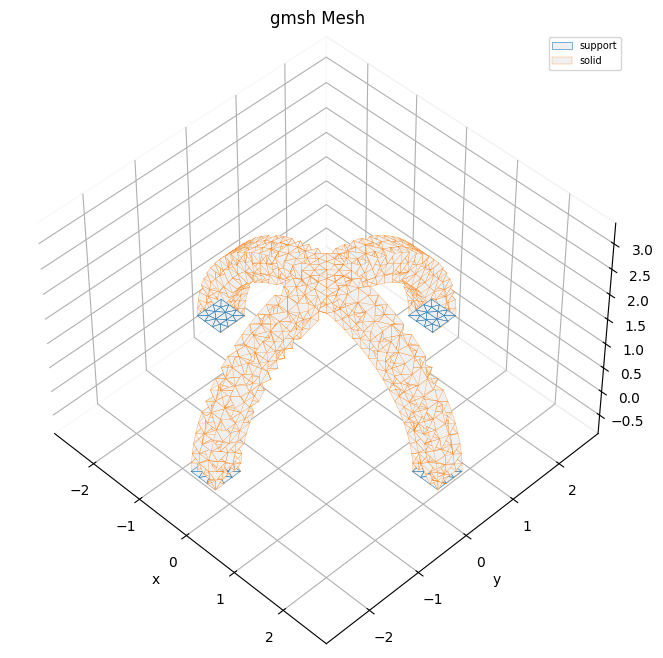

In [6]:
plot_gmsh_mesh(mesh,
               show_node_labels    = False,
               show_element_labels = False,
               show_node_points    = False,
               view_3d             = True, elev=45, azim=-45,
               figsize             = (12, 8))

In [7]:
# # Material
# Steel=Material( name='Steel',
#                 E=2000,
#                 nu=0.30,
#                 rho=1.25*tf/m**3*0)

# # Sections
# F1=Membrane(    name='F1',
#                 thickness=15,
#                 material=Steel)

# # Dictionaries
# section_dictionary={274:F1,
#                         }

# restrain_dictionary={275:['r', 'r' , 'r'] , 
#                      277: ['f' , 'f' , 'r']}

restrain_dictionary = {'support': ['r', 'r', 'r']}
load_dictionary     = {}   # no external loads — only self weight

section_dictionary  = {}   # no sections needed for OpenSees 3D


In [8]:
model = FEMModel(
    mesh                = mesh,
    section_dictionary  = section_dictionary,
    restrain_dictionary = restrain_dictionary,
    load_dictionary     = load_dictionary,
    element_class_map   = None,       # OpenSees only
    analysis_type       = '3D',
    consistent_loads    = False,
)


  FEM MODEL SUMMARY
--------------------------------------------------------------------------------
  Analysis type    : 3D
  Nodes            : 1145
  system_nDof      : 3435
  Elements         : None (OpenSees)
  Steps FEM        : 0
  Steps OpenSees   : 0

  --- Sections ---

  --- Restrained nodes ---
  Node      1  [ 2.   -0.25  0.  ]             ['r', 'r', 'r']
  Node      2  [ 2.5  -0.25  0.  ]             ['r', 'r', 'r']
  Node      5  [2.5  0.25 0.  ]                ['r', 'r', 'r']
  Node      6  [2.   0.25 0.  ]                ['r', 'r', 'r']
  Node      8  [ 0.25 -2.5   0.  ]             ['r', 'r', 'r']
  Node      9  [ 0.25 -2.    0.  ]             ['r', 'r', 'r']
  Node     13  [-0.25 -2.5   0.  ]             ['r', 'r', 'r']
  Node     14  [-0.25 -2.    0.  ]             ['r', 'r', 'r']
  Node     16  [-0.25  2.    0.  ]             ['r', 'r', 'r']
  Node     17  [0.25 2.   0.  ]                ['r', 'r', 'r']
  Node     19  [0.25 2.5  0.  ]                ['r', 'r', 'r'

In [9]:
# Mesh diagnostics
model.check_mesh()


  MESH DIAGNOSTICS
--------------------------------------------------------------------------------
  Nodes            : 1145
  system_nDof      : 3435
  Elements         : None (OpenSees)
  Physical groups  : 2

  --- Orphan nodes ---
  OK — no orphan nodes

  --- Physical groups ---
      ID   Dim  Name                    Elements     Nodes  Section
  ------  ----  --------------------  ----------  --------  ----------
      53     2  support                      104        80  MISSING
      54     3  solid                       3144      1145  MISSING

  --- Restrained nodes ---
     Tag             x             y  Condition
  ------  ------------  ------------  ------------
       1        2.0000       -0.2500  ['r', 'r', 'r']
       2        2.5000       -0.2500  ['r', 'r', 'r']
       5        2.5000        0.2500  ['r', 'r', 'r']
       6        2.0000        0.2500  ['r', 'r', 'r']
       8        0.2500       -2.5000  ['r', 'r', 'r']
       9        0.2500       -2.0000  ['r

## Opensees

In [10]:
import openseespy.opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder', '-ndm', 3, '-ndf', 3)


In [11]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y , z)

In [12]:
# Boundary conditions
fixed_nodes = set()
for tag in mesh.physical_groups['support'].nodes:
    if tag not in fixed_nodes:
        fixed_nodes.add(tag)
        # ops.fix(tag, 1, 1, 1, 1, 1, 1)
        ops.fix(tag, 1, 1, 1)

In [13]:
# Material
E = 210e9      
nu = 0.33
rho=7300
g=9.81
ops.nDMaterial('ElasticIsotropic', 1, E, nu, rho)


In [14]:
# Elements
group = mesh.physical_groups['solid'].elements
for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
    n1, n2, n3, n4 = conn
    ops.element('FourNodeTetrahedron', elem_tag, n1, n2, n3, n4, 1)

In [15]:
# opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [16]:
# Self weight — lumped to nodes
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)

nodal_weight = {}
for conn in group['connectivity']:
    n1, n2, n3, n4 = conn
    pts    = [np.array(mesh.nodes[n][:3]) for n in [n1, n2, n3, n4]]
    vol    = abs(np.dot(pts[1]-pts[0], np.cross(pts[2]-pts[0], pts[3]-pts[0]))) / 6.0
    weight = rho * g * vol / 4.0
    for tag in [n1, n2, n3, n4]:
        nodal_weight[tag] = nodal_weight.get(tag, 0.0) + weight

for tag, w in nodal_weight.items():
    ops.load(tag, 0., 0., -w)

In [17]:
NstepGravity = 10
DGravity     = 1 / NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity)
ops.test("NormUnbalance", 1.0e-6, 100, 0)
ops.algorithm("Newton")
ops.analysis("Static")

for step in range(NstepGravity):
    ops.analyze(1)
    model.set_results_opensees(ops, step=step)

In [18]:
# Animate displacements in gmsh
model.plot2gmsh_animate(disp_factor=5e4)

In [19]:
# What's in the model
print(repr(model))
print(f"\nFEM steps     : {len(model.results_fem)}")
print(f"OpenSees steps: {len(model.results_opensees)}")
print(f"Modal modes   : {len(model.results_opensees_modal) if hasattr(model, 'results_opensees_modal') else 0}")

# Modal summary
if hasattr(model, 'results_opensees_modal'):
    print(f"\n  {'Mode':>6}  {'Freq [Hz]':>12}  {'Period [s]':>12}")
    for mr in model.results_opensees_modal:
        print(f"  {mr.mode:>6}  {mr.freq:>12.4f}  {mr.period:>12.4f}")

FEMModel | nodes=1145 | elements=0 | steps_fem=0 | steps_opensees=10 | analysis=3D

FEM steps     : 0
OpenSees steps: 10
Modal modes   : 0
